notes/prepatory information for controlling pressure in chamber with mass flow controller and pressure sensor and pid controller

a control system works to limit the difference between a variable's current state and the desired state.
current state = process variable
final state = set point
difference = error signal
closed loop system: continuously monitor process variable adn adjust control inputs based on error signal.
For example a pressure controller working to maintain a specific pressure by flowing in or out gas at a set rate.


PID control works by changing control signal based on error signal and how the error signal changes in time

proportional term: measure of current error signal
integrl term: sum of error over time
derivative term: instantaneous rate of change of error signal

$
u(t) = K_pe(t) + K_i\int_0^te(\tau)d\tau + K_d\frac{de(t)}{dt}
$

In [46]:
import time
import matplotlib.pyplot as plt
import numpy as np

In [3]:
time.time()

1780339160.6513052

In [4]:
t1 = 1780338788.8948655
t2 = 1780339160.6513052
p1 = 0.9164228707948351
p2 = 4.716892543204391

t2-t1

371.75643968582153

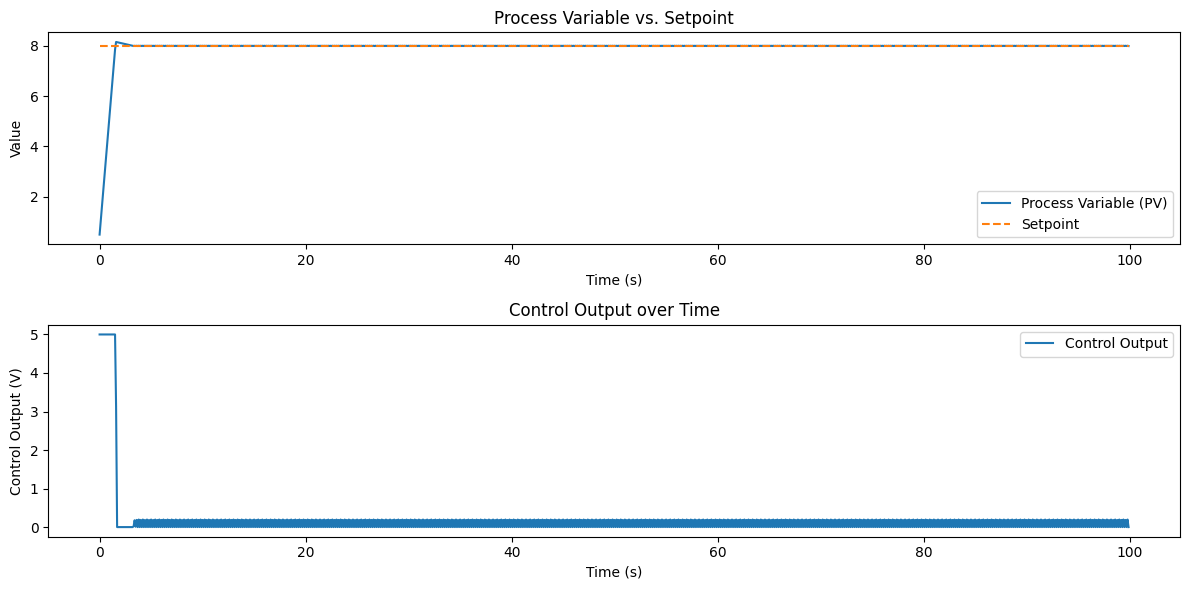

In [77]:
V = 45.30695
leak_rate = -0.43181 #Torr*L/s
leak_rate_2 = -0.202697 #Torr*L/s

leak_rate_Torr = leak_rate/V

def pid_controller(setpoint, pv, kp, ki, kd, prev_error, integral, dt):
    error = setpoint - pv
    integral += error * dt
    derivative = (error - prev_error) / dt
    control = kp * error + ki *integral + kd * derivative
    control_mod = (control*V)*(1.333224)*(1/0.0168875)*(5/100) #V
    control_clamp = max(0.0, min((5.0, control_mod)))
    return control_clamp, error, integral


critical_kp = 0.25
critical_period = 0.2 #1/5Hz

setpoint = 8
pv = 0.00
kp=0.115
# kp = critical_kp*0.6
ki = 0
kd = 0
# ki = 0.5*critical_period
# kd = critical_period/8
prev_error = 0
integral = 0
dt = 0.1

time_steps = []
pv_values = []
control_values = []
setpoint_values = []

for i in range(1000):
    control, error, integral = pid_controller(setpoint, pv, kp, ki, kd, prev_error, integral, dt)
    pv += control *dt
    pv += leak_rate_Torr

    
    time_steps.append(i*dt)
    pv_values.append(pv)
    control_values.append(control)
    setpoint_values.append(setpoint)

    #time.sleep(dt/4)
plt.figure(figsize=(12, 6))
    
plt.subplot(2, 1, 1)
plt.plot(time_steps, pv_values, label='Process Variable (PV)')
plt.plot(time_steps, setpoint_values, label='Setpoint', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Process Variable vs. Setpoint')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time_steps, control_values, label='Control Output')
plt.xlabel('Time (s)')
plt.ylabel('Control Output (V)')
plt.title('Control Output over Time')
plt.legend()

plt.tight_layout()
plt.show()

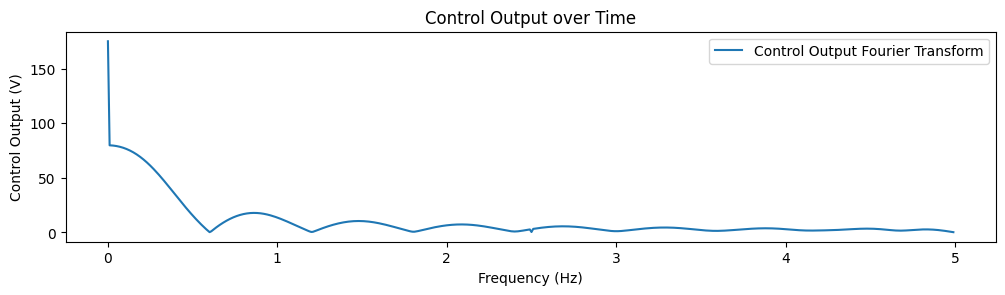

In [78]:
fft = np.fft.fft(control_values)
freq = np.fft.fftfreq(np.shape(time_steps)[-1], d = dt)
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 2)
plt.plot(freq[:len(freq)//2], np.abs(fft)[:len(freq)//2], label='Control Output Fourier Transform')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Control Output (V)')
plt.title('Control Output over Time')
plt.legend()

In [59]:
dominant_freq = freq[np.argmax(np.abs(fft)[1:len(freq)//2]) + 1]  # skip DC at index 0
period = 1 / dominant_freq  # in seconds
print("dominant freq: ", dominant_freq)

dominant freq:  0.02
